<a href="https://colab.research.google.com/github/Ariyamilaara/2318105DataVisualization/blob/main/2318105AriyaMilaaraKlasifikasiCitraMobilMetodeK_Means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **IMPORT LIBRARY**

In [ ]:
# Library standar Python
import os
import zipfile
from pathlib import Path

# Manipulasi data
import numpy as np
import pandas as pd

# Visualisasi
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Pengolahan citra
import cv2

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Pengaturan umum
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

# **1. Mount Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **2. Cek & Load Semua Gambar dari Folder Train**

In [ ]:
DATASET_PATH = '/content/drive/MyDrive/KOMPUTER VISION 2318105/Rolls Royce'

# Ambil semua file gambar
all_images = []
for ext in ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']:
    all_images.extend(Path(DATASET_PATH).rglob(ext))

all_images = sorted(all_images)

print(f'Total gambar ditemukan : {len(all_images)}')
print(f'Contoh path pertama    : {all_images[0]}')
print(f'Contoh path terakhir   : {all_images[-1]}')

Total gambar ditemukan : 312
Contoh path pertama    : /content/drive/MyDrive/KOMPUTER VISION 2318105/Rolls Royce/1.jpg
Contoh path terakhir   : /content/drive/MyDrive/KOMPUTER VISION 2318105/Rolls Royce/99.jpg


# **3. Tampilkan Sampel Gambar (Cek Visual)**

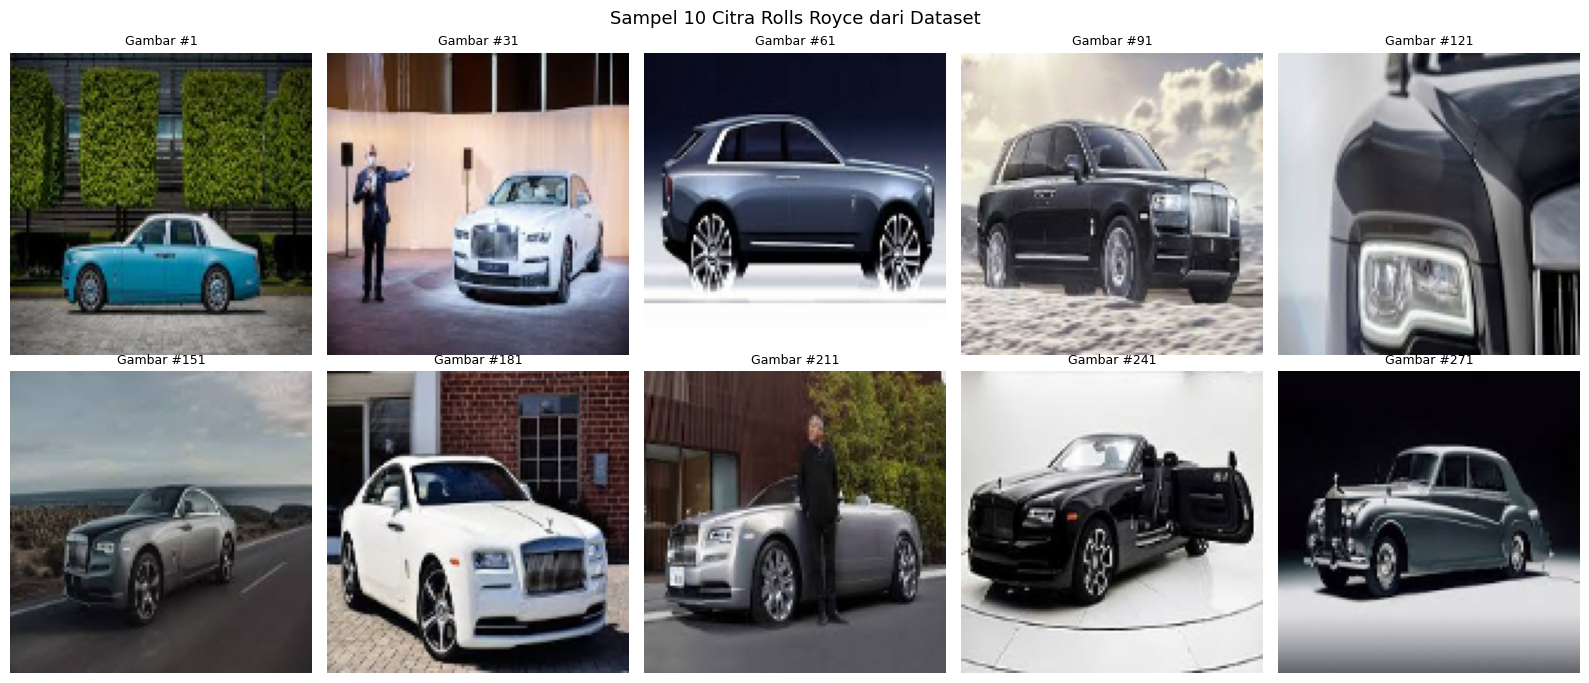

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes = axes.flatten()

for i, ax in enumerate(axes):
    img_bgr = cv2.imread(str(all_images[i * 30]))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_rgb = cv2.resize(img_rgb, (128, 128))
    ax.imshow(img_rgb)
    ax.set_title(f'Gambar #{i*30+1}', fontsize=9)
    ax.axis('off')

plt.suptitle('Sampel 10 Citra Rolls Royce dari Dataset', fontsize=13)
plt.tight_layout()
plt.show()

# **4. Ekstraksi Fitur Warna**

In [ ]:
def extract_color_features(image_path):
    """
    Mengekstrak 24 fitur warna dari satu citra:
    - 6 fitur RGB  : mean_R, std_R, mean_G, std_G, mean_B, std_B
    - 18 fitur HSV : histogram 6 bin untuk channel H, S, V
    """
    # Load dan resize gambar
    img_bgr = cv2.imread(str(image_path))
    if img_bgr is None:
        return None
    img_bgr = cv2.resize(img_bgr, (128, 128))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    features = []

    # === BAGIAN 1: Fitur RGB (6 fitur) ===
    img_float = img_rgb.astype(np.float32) / 255.0
    for ch in range(3):  # R, G, B
        channel = img_float[:, :, ch]
        features.append(np.mean(channel))
        features.append(np.std(channel))

    # === BAGIAN 2: Histogram HSV (18 fitur) ===
    n_bins = 6

    # Hue: 0-180 (skala OpenCV)
    h_hist, _ = np.histogram(img_hsv[:, :, 0], bins=n_bins, range=(0, 180))
    h_hist = h_hist.astype(np.float32) / (h_hist.sum() + 1e-6)
    features.extend(h_hist)

    # Saturation: 0-255
    s_hist, _ = np.histogram(img_hsv[:, :, 1], bins=n_bins, range=(0, 255))
    s_hist = s_hist.astype(np.float32) / (s_hist.sum() + 1e-6)
    features.extend(s_hist)

    # Value: 0-255
    v_hist, _ = np.histogram(img_hsv[:, :, 2], bins=n_bins, range=(0, 255))
    v_hist = v_hist.astype(np.float32) / (v_hist.sum() + 1e-6)
    features.extend(v_hist)

    return np.array(features, dtype=np.float32)

print('Fungsi ekstraksi fitur siap!')
print('Jumlah fitur per citra: 6 (RGB) + 18 (HSV) = 24 fitur')

Fungsi ekstraksi fitur siap!
Jumlah fitur per citra: 6 (RGB) + 18 (HSV) = 24 fitur


# **5. Ekstrak Fitur dari Semua Gambar**

In [ ]:
print('Mengekstrak fitur dari semua gambar...')

feature_matrix = []
valid_paths = []
gagal = 0

for i, path in enumerate(all_images):
    feats = extract_color_features(path)
    if feats is not None:
        feature_matrix.append(feats)
        valid_paths.append(path)
    else:
        gagal += 1

    if (i + 1) % 50 == 0:
        print(f'  {i+1}/{len(all_images)} gambar diproses...')

X = np.array(feature_matrix)

feature_names = (
    ['mean_R', 'std_R', 'mean_G', 'std_G', 'mean_B', 'std_B'] +
    [f'H_bin{i}' for i in range(6)] +
    [f'S_bin{i}' for i in range(6)] +
    [f'V_bin{i}' for i in range(6)]
)

import pandas as pd
df = pd.DataFrame(X, columns=feature_names)
df['nama_file'] = [p.name for p in valid_paths]

print(f'\nEkstraksi selesai!')
print(f'  Berhasil : {len(feature_matrix)} gambar')
print(f'  Gagal    : {gagal} gambar')
print(f'  Shape X  : {X.shape}  →  {X.shape[0]} sampel x {X.shape[1]} fitur')
print()
print(df[feature_names[:6]].describe().round(4))

Mengekstrak fitur dari semua gambar...
  50/312 gambar diproses...
  100/312 gambar diproses...
  150/312 gambar diproses...
  200/312 gambar diproses...
  250/312 gambar diproses...
  300/312 gambar diproses...

Ekstraksi selesai!
  Berhasil : 312 gambar
  Gagal    : 0 gambar
  Shape X  : (312, 24)  →  312 sampel x 24 fitur

         mean_R     std_R    mean_G     std_G    mean_B     std_B
count  312.0000  312.0000  312.0000  312.0000  312.0000  312.0000
mean     0.4386    0.2510    0.4330    0.2461    0.4291    0.2484
std      0.1730    0.0639    0.1673    0.0630    0.1666    0.0627
min      0.0357    0.0694    0.0718    0.0683    0.0798    0.0754
25%      0.3400    0.2212    0.3351    0.2147    0.3294    0.2123
50%      0.4452    0.2548    0.4364    0.2485    0.4234    0.2488
75%      0.5509    0.2852    0.5332    0.2800    0.5155    0.2858
max      0.8849    0.4268    0.8897    0.4088    0.9001    0.4125


# **6. Normalisasi Fitur**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Normalisasi StandardScaler selesai.')
print(f'  Mean setelah scaling (harusnya ~0): {X_scaled.mean(axis=0)[:3].round(4)}')
print(f'  Std setelah scaling  (harusnya ~1): {X_scaled.std(axis=0)[:3].round(4)}')

Normalisasi StandardScaler selesai.
  Mean setelah scaling (harusnya ~0): [0. 0. 0.]
  Std setelah scaling  (harusnya ~1): [1. 1. 1.]


# **7. Elbow Method: Cari Nilai K Optimal**

Menghitung Elbow & Silhouette untuk K=2 sampai K=10...
  K= 2 | Inertia=   5978.40 | Silhouette=0.2714
  K= 3 | Inertia=   5097.60 | Silhouette=0.1927
  K= 4 | Inertia=   4737.05 | Silhouette=0.1272
  K= 5 | Inertia=   4426.65 | Silhouette=0.1343
  K= 6 | Inertia=   4144.35 | Silhouette=0.1332
  K= 7 | Inertia=   3981.43 | Silhouette=0.1289
  K= 8 | Inertia=   3855.38 | Silhouette=0.1236
  K= 9 | Inertia=   3751.19 | Silhouette=0.1277
  K=10 | Inertia=   3634.26 | Silhouette=0.1196


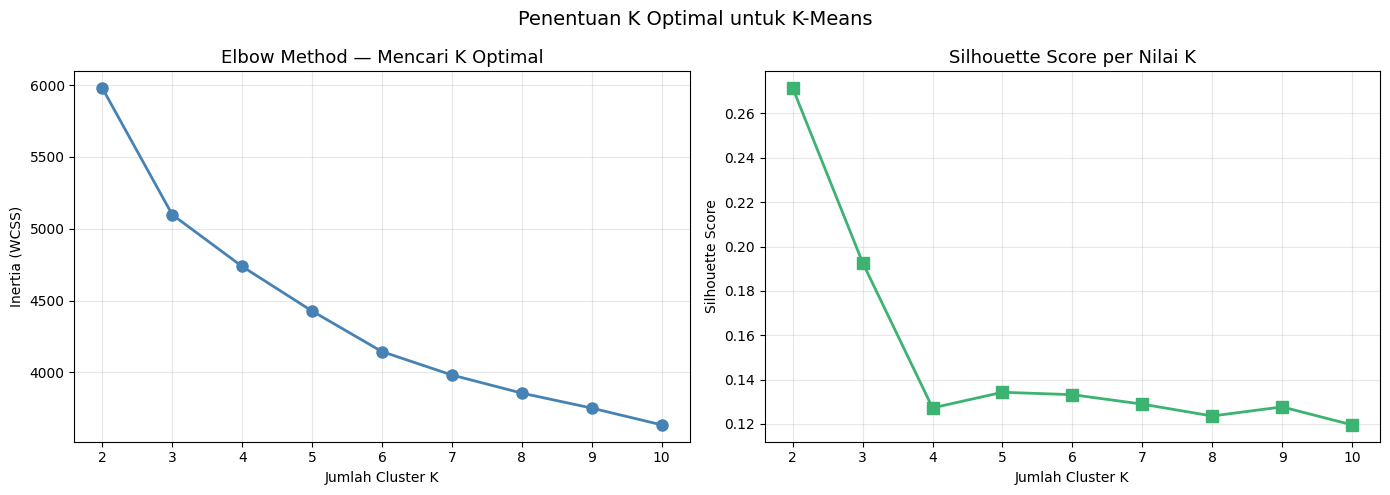


K terbaik berdasarkan Silhouette Score: K = 2


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_range = range(2, 11)
inertias = []
sil_scores = []

print('Menghitung Elbow & Silhouette untuk K=2 sampai K=10...')
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, km.labels_)
    sil_scores.append(sil)
    print(f'  K={k:2d} | Inertia={km.inertia_:10.2f} | Silhouette={sil:.4f}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, 'o-', color='steelblue', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method — Mencari K Optimal', fontsize=13)
axes[0].set_xlabel('Jumlah Cluster K')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_xticks(list(k_range))
axes[0].grid(alpha=0.3)

axes[1].plot(k_range, sil_scores, 's-', color='mediumseagreen', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score per Nilai K', fontsize=13)
axes[1].set_xlabel('Jumlah Cluster K')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(k_range))
axes[1].grid(alpha=0.3)

plt.suptitle('Penentuan K Optimal untuk K-Means', fontsize=14)
plt.tight_layout()
plt.show()

best_k = list(k_range)[sil_scores.index(max(sil_scores))]
print(f'\nK terbaik berdasarkan Silhouette Score: K = {best_k}')

# **8. Perhitungan K-Means**

In [ ]:
K_OPTIMAL = best_k   # otomatis dari Sel 7, atau ganti manual misal: K_OPTIMAL = 4

print('=' * 55)
print('   PROSES K-MEANS CLUSTERING')
print('=' * 55)

np.random.seed(42)
idx_awal = np.random.choice(len(X_scaled), size=K_OPTIMAL, replace=False)
centroids = X_scaled[idx_awal].copy()
print(f'\nTAHAP 1 — Inisialisasi')
print(f'  K = {K_OPTIMAL} cluster')
print(f'  Centroid awal dipilih dari indeks: {idx_awal}')

print(f'\nTAHAP 2 — Iterasi Assignment & Update Centroid')

labels_prev = np.full(len(X_scaled), -1)

for iterasi in range(1, 301):

      # --- Hitung jarak tiap titik ke semua centroid ---
    # Jarak Euclidean: sqrt( sum( (x_i - c_k)^2 ) )
    distances = np.zeros((len(X_scaled), K_OPTIMAL))
    for k in range(K_OPTIMAL):
        diff = X_scaled - centroids[k]          # selisih tiap fitur
        distances[:, k] = np.sqrt((diff ** 2).sum(axis=1))  # jarak Euclidean

    # Tiap titik masuk ke cluster dengan jarak TERKECIL
    labels = np.argmin(distances, axis=1)


    # --- CEK KONVERGENSI ---
    if np.all(labels == labels_prev):
        print(f'  Konvergen pada iterasi ke-{iterasi}!')
        break
    labels_prev = labels.copy()

    # --- UPDATE: geser centroid ke rata-rata anggotanya ---
    for k in range(K_OPTIMAL):
        anggota = X_scaled[labels == k]
        if len(anggota) > 0:
            centroids[k] = anggota.mean(axis=0)  # mean semua titik di cluster k

    if iterasi <= 5 or iterasi % 10 == 0:
        inertia_iter = sum(
            ((X_scaled[labels == k] - centroids[k]) ** 2).sum()
            for k in range(K_OPTIMAL)
        )
        print(f'  Iterasi {iterasi:3d} | Inertia = {inertia_iter:.4f}')

inertia_final = 0
for k in range(K_OPTIMAL):
    anggota = X_scaled[labels == k]
    if len(anggota) > 0:
        # WCSS: jumlah kuadrat jarak tiap titik ke centroidnya
        inertia_final += ((anggota - centroids[k]) ** 2).sum()

print(f'\nTAHAP 3 — Hasil Akhir')
print(f'  Inertia (WCSS) final : {inertia_final:.4f}')
print(f'  Silhouette Score     : {silhouette_score(X_scaled, labels):.4f}')
print()

# Distribusi anggota tiap cluster
print('  Distribusi cluster:')
for k in range(K_OPTIMAL):
    n = (labels == k).sum()
    pct = n / len(labels) * 100
    print(f'    Cluster {k}: {n:4d} gambar  ({pct:.1f}%)')

# Simpan labels ke DataFrame
df['cluster'] = labels
print('\nLabel cluster berhasil disimpan ke DataFrame!')

   PROSES K-MEANS CLUSTERING

TAHAP 1 — Inisialisasi
  K = 2 cluster
  Centroid awal dipilih dari indeks: [228   9]

TAHAP 2 — Iterasi Assignment & Update Centroid
  Iterasi   1 | Inertia = 6140.2705
  Iterasi   2 | Inertia = 6090.2920
  Iterasi   3 | Inertia = 6067.9082
  Iterasi   4 | Inertia = 6048.1260
  Iterasi   5 | Inertia = 6031.8765
  Iterasi  10 | Inertia = 6000.7944
  Konvergen pada iterasi ke-11!

TAHAP 3 — Hasil Akhir
  Inertia (WCSS) final : 6000.7944
  Silhouette Score     : 0.1696

  Distribusi cluster:
    Cluster 0:  167 gambar  (53.5%)
    Cluster 1:  145 gambar  (46.5%)

Label cluster berhasil disimpan ke DataFrame!


# **9. Visualisasi Hasil**

Variansi dijelaskan PC1: 32.9%  |  PC2: 10.2%  |  Total: 43.1%


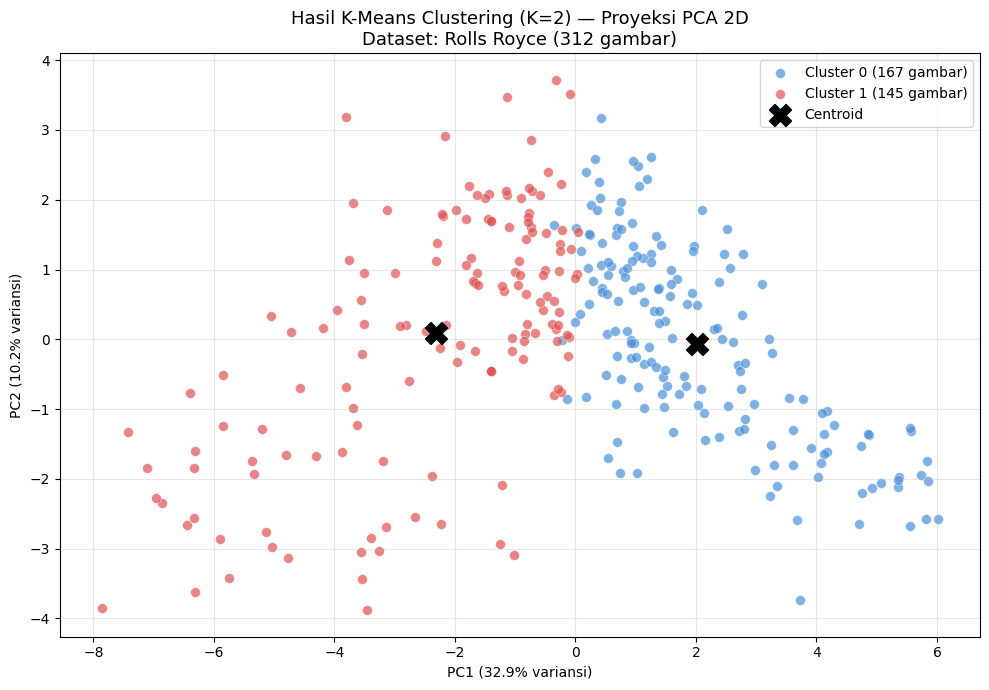

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

ev = pca.explained_variance_ratio_
print(f'Variansi dijelaskan PC1: {ev[0]*100:.1f}%  |  PC2: {ev[1]*100:.1f}%  |  Total: {sum(ev)*100:.1f}%')

WARNA = ['#4A90D9', '#E05252', '#47B87A', '#F0A500', '#9B59B6']

plt.figure(figsize=(10, 7))
for k in range(K_OPTIMAL):
    mask = labels == k
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=WARNA[k % len(WARNA)], label=f'Cluster {k} ({mask.sum()} gambar)',
                alpha=0.7, s=50, edgecolors='white', linewidth=0.4)

# Plot centroid di ruang PCA
centroids_pca = pca.transform(centroids)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            c='black', marker='X', s=250, zorder=6, label='Centroid')

plt.title(f'Hasil K-Means Clustering (K={K_OPTIMAL}) — Proyeksi PCA 2D\nDataset: Rolls Royce ({len(X_scaled)} gambar)', fontsize=13)
plt.xlabel(f'PC1 ({ev[0]*100:.1f}% variansi)')
plt.ylabel(f'PC2 ({ev[1]*100:.1f}% variansi)')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('hasil_kmeans_pca.png', dpi=150, bbox_inches='tight')
plt.show()

# **10. Tampilkan Sampel Gambar per Cluster**

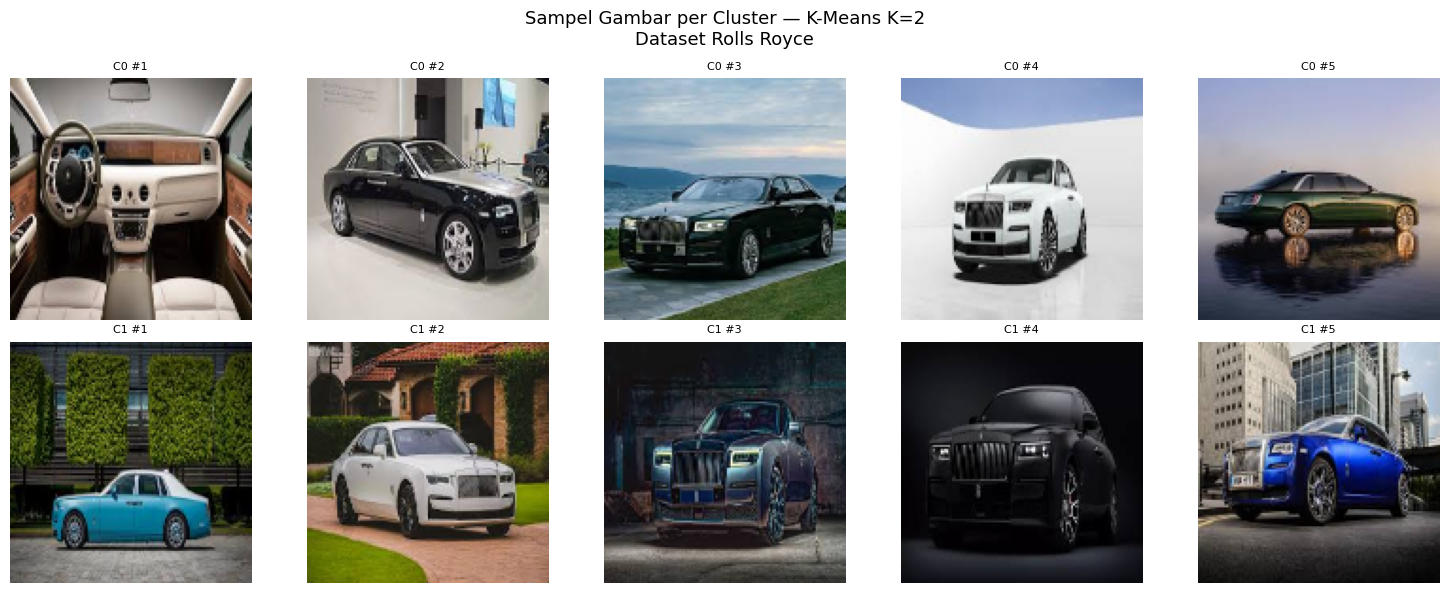

In [ ]:
fig, axes = plt.subplots(K_OPTIMAL, 5, figsize=(15, 3 * K_OPTIMAL))
fig.suptitle(f'Sampel Gambar per Cluster — K-Means K={K_OPTIMAL}\nDataset Rolls Royce', fontsize=13)

for k in range(K_OPTIMAL):
    idx_cluster = np.where(labels == k)[0]
    sampel = idx_cluster[:5]  # ambil 5 sampel pertama

    for col, idx in enumerate(sampel):
        ax = axes[k][col] if K_OPTIMAL > 1 else axes[col]
        img_bgr = cv2.imread(str(valid_paths[idx]))
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_rgb = cv2.resize(img_rgb, (128, 128))
        ax.imshow(img_rgb)
        ax.set_title(f'C{k} #{col+1}', fontsize=8)
        ax.axis('off')

plt.tight_layout()
plt.savefig('sampel_per_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

# **11. Ringkasan & Evaluasi Akhir**

In [ ]:
from sklearn.metrics import davies_bouldin_score

sil  = silhouette_score(X_scaled, labels)
db   = davies_bouldin_score(X_scaled, labels)

print('=' * 55)
print('   RINGKASAN HASIL')
print('=' * 55)
print(f'  Dataset          : Rolls Royce (Kaggle)')
print(f'  Total gambar     : {len(X_scaled)}')
print(f'  Jumlah fitur     : {X.shape[1]} (6 RGB + 18 HSV)')
print(f'  Metode ML        : K-Means Clustering')
print(f'  K optimal        : {K_OPTIMAL}')
print()
print('  METRIK EVALUASI:')
print(f'  Silhouette Score : {sil:.4f}  (mendekati 1 = bagus)')
print(f'  Davies-Bouldin   : {db:.4f}  (mendekati 0 = bagus)')
print(f'  Inertia (WCSS)   : {inertia_final:.2f}')
print()
print('  DISTRIBUSI CLUSTER:')
for k in range(K_OPTIMAL):
    n = (labels == k).sum()
    print(f'    Cluster {k}: {n} gambar ({n/len(labels)*100:.1f}%)')
print('=' * 55)

# Simpan dataset fitur + hasil cluster ke CSV
df.to_csv('hasil_kmeans_rollsroyce.csv', index=False)
print('\nFile tersimpan: hasil_kmeans_rollsroyce.csv')

from google.colab import files
files.download('hasil_kmeans_rollsroyce.csv')

   RINGKASAN HASIL
  Dataset          : Rolls Royce (Kaggle)
  Total gambar     : 312
  Jumlah fitur     : 24 (6 RGB + 18 HSV)
  Metode ML        : K-Means Clustering
  K optimal        : 2

  METRIK EVALUASI:
  Silhouette Score : 0.1696  (mendekati 1 = bagus)
  Davies-Bouldin   : 1.9119  (mendekati 0 = bagus)
  Inertia (WCSS)   : 6000.79

  DISTRIBUSI CLUSTER:
    Cluster 0: 167 gambar (53.5%)
    Cluster 1: 145 gambar (46.5%)

File tersimpan: hasil_kmeans_rollsroyce.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>